In [111]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/jaxley_rgc
    !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"

In [112]:
from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
import jax
from jax.nn import softplus
import jax.numpy as jnp
from utils.training_utils import K_func, ln_forward, make_rgc_forward_with_states
from utils.utils import upsample_hold_edges
from utils.v_to_rate import voltage_batch_to_mu, make_edges
from utils.rgc import build_cell, simulate_one_trial, rgc_forward_sim
from utils.spk_detection import voltage_batch_to_spikes, idx_to_times

import matplotlib.pyplot as plt
import jaxley as jx
plt.rcParams["figure.dpi"] = 100
plt.rcParams['axes.labelsize'] = 18

import seaborn as sns

## To Do:
- Prove with 10s long stim
- Initialize with STA
- Revisar bien bien params y scale factors.
- Clamp collinear params
- Add gain as part of the NL visuals. Fix beta, fix DC, 

In [113]:
import jax, jax.numpy as jnp
print("Default backend:", jax.default_backend())
print("Devices:", jax.devices())

x = jnp.arange(10)
print("x placed on:", x.devices() if hasattr(x, "devices") else x.device())



Default backend: cpu
Devices: [CpuDevice(id=0)]
x placed on: {CpuDevice(id=0)}


In [114]:
from utils.stim_utils import generate_1_f_noise, plot_stim

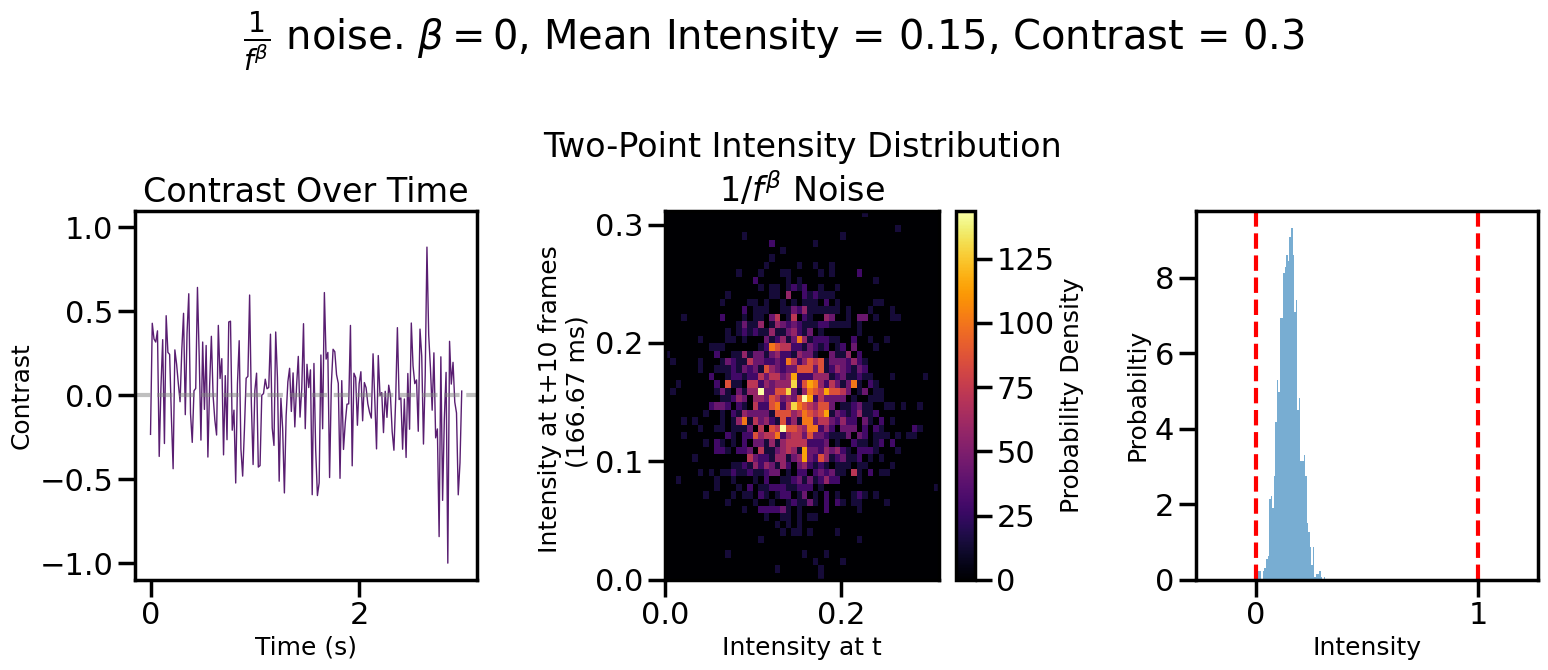

In [115]:
beta= 0
mean_intensity = 0.15
desired_contrast = 0.3
stim_duration = 3
trials = 10
frame_rate = 60
frame_dwell = 1
tau = 10

all_noise = []
all_contrast = []
for trial in range(trials):
    noise, contrast = generate_1_f_noise(
        beta, frame_rate * stim_duration, frame_rate,
        frame_dwell, mean_intensity, desired_contrast,
        noise_seed=trial)
    all_noise.append(noise)
    all_contrast.append(contrast)

noise_t = jnp.concatenate(all_noise)
contrast_t = jnp.concatenate(all_contrast)
stim = jnp.array(all_contrast)

plot_stim(noise_t=noise_t, contrast_mat=stim,
          beta=beta,
          mean_intensity=mean_intensity,
          desired_contrast=desired_contrast,
          tau=10, frame_rate=60, figsize=(16,7))

In [116]:
def softplus_inv(y, eps=1e-8):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))

def ln_params(key,
              alpha_j0,
              alpha_h0,
              logit_tau10,
              logit_tau20,
              beta0,
              gain0,
              shift0,
              noise,
              beta_rate_raw,
              vth_rate):
    eps = noise * jax.random.normal(key, (7,), dtype=jnp.float32)
    return {
      "logit_tau1": jnp.array(logit_tau10, jnp.float32) + eps[0],
      "logit_tau2": jnp.array(logit_tau20, jnp.float32) + eps[1],
      "alpha_j":    jnp.array(alpha_j0,   jnp.float32)  * (1.0 + 0.1*eps[2]),
      "alpha_h":    jnp.array(alpha_h0,   jnp.float32)  * (1.0 + 0.1*eps[3]),
      "log_beta": softplus_inv(beta0) + eps[4],
      "log_gain": softplus_inv(gain0) + eps[5],  # Start with gain ~ 1.0
      "shift":      jnp.array(shift0, jnp.float32) + 0.05*eps[6],
      # "scale": jnp.array(scale, jnp.float32),
      "beta_rate_raw": jnp.array(beta_rate_raw, jnp.float32),
      "vth_rate": jnp.array(vth_rate, jnp.float32),
    }



In [117]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate

dt_cell_ms = 0.05
dt_cell_s = dt_cell_ms * 1e-3
key = jax.random.PRNGKey(0)
ground_params = ln_params(key,
                        alpha_j0=0.16,
                        alpha_h0=0.38,
                        logit_tau10=0.55,
                        logit_tau20=-0.57,
                        beta0=0.25,
                        gain0=0.15,
                        shift0=0.304,
                        noise=0.00,
                        beta_rate_raw=0.0,
                        vth_rate=-0.0)


filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive, L, K_ground =  ln_forward(ground_params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


In [118]:
# I_frame_ground = current_map(drive, ground_params)
I_frame_ground = drive
T_f = I_frame_ground.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell_s))
I_syn_ground = upsample_hold_edges(I_frame_ground, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

# Build cell
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")
V_batch = rgc_forward_sim(I_syn_ground, dt_cell_ms, cell0)  # dt_cell_ms should be in the same units integrate expects
print(V_batch.shape)

Added 1 recordings. See `.recordings` for details.
(10, 60000)


In [119]:
T_v = V_batch.shape[1]
edges_hat = make_edges(T_v, sr_v=1/dt_cell_s, fr=60.0)
rate_hat, mu_hat = voltage_batch_to_mu(V_batch, edges_hat, vth=-30, beta=0.5, r_max_hz=100, vcap=-20)

### Visualize V to rate diff transformation

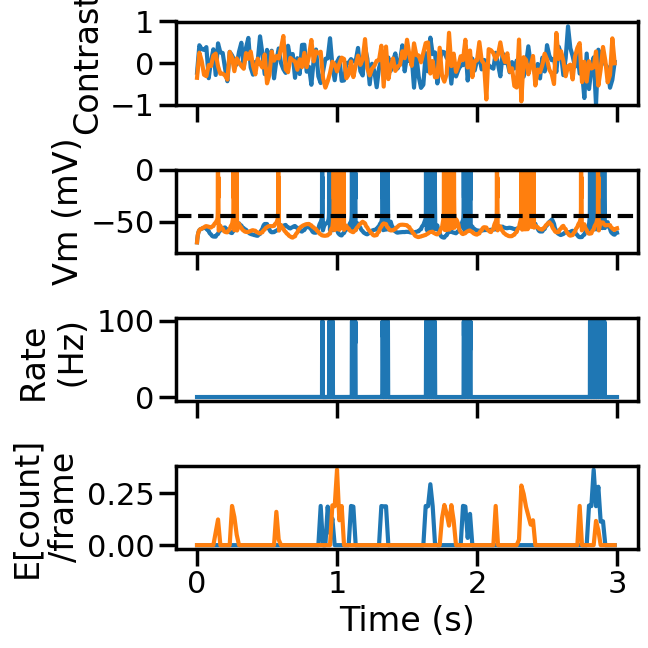

In [120]:

fig, axes = plt.subplots(4,1, sharex=True, figsize=(7,7))
t = jnp.arange(len(V_batch[1])) * dt_cell_s
t_stim = jnp.arange(len(mu_hat[0]))/60
axes[0].plot(t_stim, stim[0]) ; axes[0].plot(t_stim, stim[1])
axes[1].plot(t, V_batch[0]); axes[1].plot(t, V_batch[1])
axes[1].axhline(-45, ls="--", c='k')
axes[1].set_ylim(-80, 0)
axes[2].plot(t, rate_hat[0])

axes[3].plot(t_stim, mu_hat[0]) ; axes[3].plot(t_stim, mu_hat[1])

axes[0].set_ylabel("Contrast")
axes[0].set_ylim(-1,1)
axes[1].set_ylabel("Vm (mV)")
axes[2].set_ylabel("Rate \n (Hz)")
axes[3].set_ylabel("E[count]\n/frame")
axes[3].set_xlabel("Time (s)")

fig.tight_layout()

## Spike detection

In [121]:
T_v = V_batch.shape[1]
edges_hat = make_edges(T_v, sr_v=1/dt_cell_s, fr=60.0)


spk_bool, spk_idx_padded, n_spk, spk_train_60 = voltage_batch_to_spikes(
    V_batch,
    dt_v=dt_cell_s,
    edges=edges_hat,
    vth=0.0,        # try 0mV first; if too strict/lenient change to e.g. -10 or +10
    refrac_ms=2.0
)

spk_times_padded = idx_to_times(spk_idx_padded, dt_cell_s)

print("spk_bool:", spk_bool.shape)                 # (50, T_v)
print("spk_train_60:", spk_train_60.shape)         # (50, T_f)
print("n_spk (first 10):", n_spk[:10])


spk_bool: (10, 60000)
spk_train_60: (10, 180)
n_spk (first 10): [33 29 37 32 27 36 25 26 31 35]


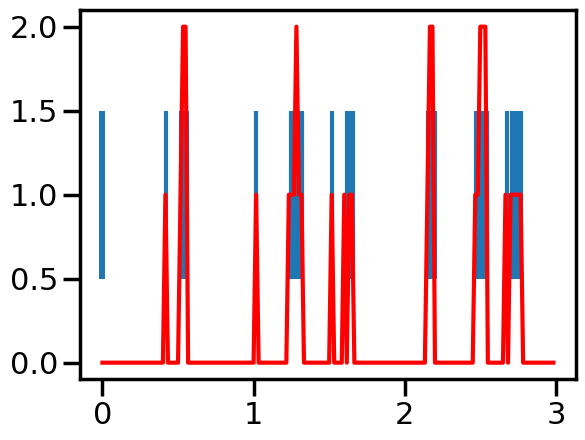

In [122]:
_ = jnp.arange(spk_train_60.shape[1]) / 60
plt.eventplot(spk_times_padded[2])
plt.plot(_, spk_train_60[2], c='red')

In [123]:
jnp.mean(spk_train_60)

Array(0.17277779, dtype=float32)

In [124]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate

key2 = jax.random.PRNGKey(1)
# params_ln0 = init_fit_params(key2)
params_ln0 = ln_params(key2, alpha_j0=1.1,
                        alpha_h0=0.95,
                        logit_tau10=1.1,
                        logit_tau20=1.375,
                        beta0=0.25,
                        gain0 = 0.5,
                        shift0=0.30,
                        noise=0.05,
                        beta_rate_raw=0.0,
                        vth_rate=-30.0)

filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
I_frame0, L, K0 =  ln_forward(params_ln0, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)

/tmp/ipykernel_5595/1846855679.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout(w_pad=0.1)


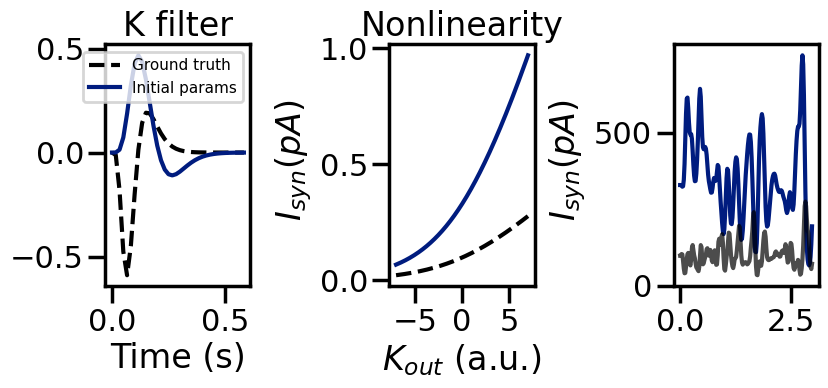

In [125]:
from jax.numpy.linalg import norm
t_k = jnp.arange(len(drive[0]))/frame_rate
# sns.set_palette("dark")
fig, axes = plt.subplots(1, 3, figsize=(6*1.5, 4*1.1),  layout="constrained")


axes[0].plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth',)

axes[0].plot(jnp.arange(len(K0))*dt_stim, K0/norm(K0), c=sns.color_palette("dark")[0], label='Initial params')

axes[0].set_xlabel("Time (s)")
axes[0].set_title("K filter")

axes[1].set_title("Nonlinearity")

x = jnp.linspace(-7, 7, 300)

beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
gain0  = softplus(params_ln0["log_gain"]) + 1e-6
nl0 = gain0 * softplus(beta0 * (x - shift0))

beta_ground  = softplus(ground_params["log_beta"]) + 1e-6
shift_ground = ground_params["shift"]
gain_ground  = softplus(ground_params["log_gain"]) + 1e-6
nl_ground = gain_ground * softplus(beta_ground * (x - shift_ground))


axes[1].plot(x, nl0, label='Initial params', c=sns.color_palette("dark")[0])
axes[1].plot(x, nl_ground ,c='k', ls="--", label='Ground truth')
axes[1].set_xlabel(r"$K_{out}$ (a.u.)")
axes[1].set_ylabel(r" $I_{syn} (pA)$")
axes[0].legend(loc= 'upper right', fontsize=11)

axes[2].plot(t_stim,I_frame0[0]*1000, c=sns.color_palette("dark")[0])
axes[2].plot(t_stim,I_frame_ground[0]*1000, c='k', alpha=0.7)
axes[2].set_ylabel(r" $I_{syn} (pA)$")
fig.tight_layout(w_pad=0.1)


In [126]:
def poisson_nll(mu, y, eps=1e-8):
    mu = jnp.clip(mu, eps, 1e9)
    return jnp.mean(mu - y * jnp.log(mu))  # + const (ignored)


import optax

# --- You already have these ---
# stim: (B, T_f) contrast per frame
# cell0: built cell
# dt_stim, dt_cell_s, dt_cell_ms, edges_hat, K_T, max_tau

def predict_mu_from_params(params, stim):
    # 1) LN
    drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)

    # 2) Drive -> current per frame
    # I_frame = current_map(drive, params)  # (B, T_f)
    I_frame = drive  # (B, T_f)
    # 3) Upsample to cell timestep
    T_f = I_frame.shape[-1]
    T_cell = int(round(T_f * dt_stim / dt_cell_s))
    I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)  # (B, T_v)

    # 4) Biophysical RGC voltage (uses captured cell + states)
    V_batch = rgc_forward(I_syn)  # (B, T_v)

    # 5) Voltage -> rate -> mu/frame (use learnable head)
    beta_rate = jax.nn.softplus(params["beta_rate_raw"]) + 1e-3
    vth_rate  = params["vth_rate"]

    rate_batch, mu_batch = voltage_batch_to_mu(
        V_batch, edges_hat,
        vth=vth_rate, beta=beta_rate, r_max_hz=100, vcap=-20
    )
    return mu_batch



In [127]:
import jax
import jax.numpy as jnp
import optax
from jax.nn import softplus

y_counts = spk_train_60.astype(jnp.float32)

# -------------------------
# Priors / penalty settings
# -------------------------
BETA_PRIOR    = 0.25
SIGMA_LOGBETA = 1.0
LAM_BETA      = 1e-2

SIGMA_MEAN    = 1.0
LAM_MEAN      = 1e-1


def beta_from_params(params, eps=1e-6):
    return softplus(params["log_beta"]) + eps

def beta_prior_penalty(params, beta_prior=BETA_PRIOR, sigma_logbeta=SIGMA_LOGBETA):
    beta = beta_from_params(params)
    logb  = jnp.log(beta)
    logb0 = jnp.log(jnp.asarray(beta_prior, dtype=logb.dtype))
    return ((logb - logb0) / sigma_logbeta) ** 2

def mean_rate_penalty(mu_hat, y_counts, sigma_mean=SIGMA_MEAN):
    dm = jnp.mean(mu_hat) - jnp.mean(y_counts)
    return (dm / sigma_mean) ** 2


def loss_fn_with_priors(params, stim, y_counts):
    mu_hat = predict_mu_from_params(params, stim)
    data = poisson_nll(mu_hat, y_counts)
    reg_beta = beta_prior_penalty(params)
    reg_mean = mean_rate_penalty(mu_hat, y_counts)
    return data + LAM_BETA * reg_beta + LAM_MEAN * reg_mean


# -------------------------
# Optimizer with FROZEN head
# -------------------------
FREEZE_KEYS = {"beta_rate_raw", "vth_rate"}

def label_fn(path, v):
    k0 = path[0]
    k = k0.key if hasattr(k0, "key") else str(k0)

    if k in FREEZE_KEYS:
        return "frozen"
    # "gain" group kept for compatibility; you can remove if unused
    if k in ["log_gain"]:
        return "gain"
    return "ln"

param_labels = jax.tree_util.tree_map_with_path(label_fn, params_ln0)

tx = optax.multi_transform(
    {
        "ln":     optax.adam(3e-3),
        "gain":   optax.adam(1e-2),
        "frozen": optax.set_to_zero(),   # <-- freezes those leaves
    },
    param_labels
)

opt_state = tx.init(params_ln0)

batch_size = 2

@jax.jit
def train_step_minibatch(params, opt_state, stim, y_counts, key):
    B_total = stim.shape[0]
    idx = jax.random.randint(key, (batch_size,), 0, B_total)
    stim_b = stim[idx]
    y_b    = y_counts[idx]

    loss, grads = jax.value_and_grad(loss_fn_with_priors)(params, stim_b, y_b)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


In [128]:
T_f = I_frame0.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell_s))
I_syn0= upsample_hold_edges(I_frame0, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)


In [129]:
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")

rgc_forward = make_rgc_forward_with_states(cell0, dt_cell_ms)  # returns a function forward(I_syn)
rgc_forward = jax.jit(rgc_forward)
_ = rgc_forward(I_syn0).block_until_ready()

Added 1 recordings. See `.recordings` for details.


In [130]:
import optax

FREEZE_KEYS = {"beta_rate_raw", "vth_rate"}

def make_mask(params, freeze_keys=FREEZE_KEYS):
    return {k: (k not in freeze_keys) for k in params.keys()}

mask = make_mask(params_ln0)

In [ ]:
log_every = 50
n_steps = 500
n_logs = n_steps // log_every + 1

loss_log = jnp.zeros((n_logs,), dtype=jnp.float32)
log_i = 0

params = params_ln0  # <-- important: start from init ONCE

key = jax.random.PRNGKey(0)
for it in range(n_steps):
    key, sub = jax.random.split(key)
    params, opt_state, loss = train_step_minibatch(params, opt_state, stim, y_counts, sub)

    if it % log_every == 0:
        loss_log = loss_log.at[log_i].set(loss.astype(jnp.float32))
        print(it, float(jax.device_get(loss)))

        mu_hat_dbg = predict_mu_from_params(params, stim[:2])
        print("beta", float(beta_from_params(params)),
              "reg_beta", float(beta_prior_penalty(params)),
              "reg_mean", float(mean_rate_penalty(mu_hat_dbg, y_counts[:2])),
              "mean(mu)", float(jnp.mean(mu_hat_dbg)),
              "mean(y)", float(jnp.mean(y_counts[:2])))

        log_i += 1

loss_log_np = jax.device_get(loss_log)



0 0.7908804772876568
beta 0.2650575637817383 reg_beta 0.003420624416321516 reg_mean 0.009700275294192833 mean(mu) 0.2707122024606989 mean(y) 0.17222222685813904


In [ ]:
loss_log_np = jax.device_get(loss_log)
y = y_counts
mu0 = jnp.full_like(y, jnp.mean(y))
base_const = poisson_nll(mu0, y)
print(base_const)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import jax
# import jax.numpy as jnp

# # pick which params to track
# track_keys = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

# def snapshot(params, keys):
#     # convert to plain python floats for easy plotting
#     out = {}
#     for k in keys:
#         out[k] = float(jax.device_get(params[k]))
#     return out

# # storage
# hist = {k: [] for k in track_keys}
# loss_hist = []

# opt_state = optimizer.init(params)

# # compile once
# train_step = jax.jit(train_step)

# log_every = 25

# loss_hist = []
# hist = {k: [] for k in track_keys}

# for it in range(301):
#     params, opt_state, loss = train_step(params, opt_state, stim, y_counts)

#     if it % log_every == 0:
#         loss_val = float(jax.device_get(loss))   # sync only occasionally
#         print(it, loss_val)
#         loss_hist.append(loss_val)

#         snap = snapshot(params, track_keys)      # only occasionally
#         for k in track_keys:
#             hist[k].append(snap[k])


In [ ]:
# # Run one forward pass (no jit) and inspect devices
# drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)
# I_frame = current_map(drive, params)
# T_f = I_frame.shape[-1]
# T_cell = int(round(T_f * dt_stim / dt_cell_s))
# I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

# print("I_syn device:", I_syn.device if hasattr(I_syn, "device") else "host")

# V_batch = rgc_forward(I_syn)
# print("V_batch device:", V_batch.device if hasattr(V_batch, "device") else "host")

# mu = predict_mu_from_params(params, stim)
# print("mu device:", mu.device if hasattr(mu, "device") else "host")

# loss0 = loss_fn(params, stim, y_counts)
# print("loss device:", loss0.device if hasattr(loss0, "device") else "host")


In [ ]:
# ---- loss ----
plt.figure()
plt.plot(loss_hist)
plt.xlabel("iteration")
plt.ylabel("Poisson NLL")
plt.title("Training loss")
plt.show()

# ---- params (small multiples) ----
keys_to_plot = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

n = len(keys_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(12, 3*nrows))
for i, k in enumerate(keys_to_plot, 1):
    plt.subplot(nrows, ncols, i)
    plt.plot(hist[k])
    plt.title(k)
    plt.xlabel("iteration")
plt.tight_layout()
plt.show()


In [ ]:
loss, grads = jax.value_and_grad(loss_fn)(params, stim, y_counts)

def gnorm(x):
    return float(jax.device_get(jnp.linalg.norm(jnp.ravel(x))))

for k in ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]:
    print(k, gnorm(grads[k]), " param:", float(jax.device_get(params[k])))
print("loss:", float(jax.device_get(loss)))


In [ ]:
k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=6, max_tau=max_tau
    )

k_np = np.array(jax.device_get(k))



In [ ]:
from jax.numpy.linalg import norm
t_k = jnp.arange(len(drive[0]))/frame_rate
# sns.set_palette("dark")
fig, axes = plt.subplots(1, 2, figsize=(6*1.1, 4*1.1),  layout="constrained")


axes[0].plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth',)

axes[0].plot(jnp.arange(len(K0))*dt_stim, K0/norm(K0), c=sns.color_palette("dark")[0], label='Initial params')
axes[0].plot(np.arange(len(k_np)) * float(dt_stim) , k_np/norm(k_np), label="learned")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("K filter")

axes[1].set_title("Nonlinearity")

x = jnp.linspace(-7, 7, 300)

beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
nl0 = softplus(beta0 * (x - shift0))

beta_ground  = softplus(ground_params["log_beta"]) + 1e-6
shift_ground = ground_params["shift"]
nl_ground = softplus(beta_ground * (x - shift_ground))


beta_learned  = softplus(params["log_beta"]) + 1e-6
shift_learned = params["shift"]
nl_learned = softplus(beta_learned * (x - shift_learned))

axes[1].plot(x, nl0, label='Initial params', c=sns.color_palette("dark")[0])
axes[1].plot(x, nl_ground ,c='k', ls="--", label='Ground truth')
axes[1].plot(x, nl_learned, )
axes[1].set_xlabel(r"$K_{out}$ (a.u.)")
axes[0].legend(loc= 'upper right', fontsize=11)
fig.tight_layout(w_pad=0.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.nn import sigmoid, softplus

def get_ln_objects(params, stim, *, K_T, dt_stim, n, max_tau):
    # tau in seconds (since dt_stim is seconds)
    tau_j = sigmoid(params["logit_tau1"]) * max_tau
    tau_h = sigmoid(params["logit_tau2"]) * max_tau

    k = K_func(tau_j, tau_h, n, params["alpha_j"], params["alpha_h"], K_T, dt_stim)

    # L2 normalization (same as your ln_forward)
    eps = 1e-12
    k = k / (jnp.sqrt(jnp.sum(k**2) * dt_stim) + eps)

    # linear stage
    def conv1(tr):
        return jnp.convolve(tr, k, mode="full")[:tr.shape[0]]

    L = jax.vmap(conv1)(stim) if stim.ndim == 2 else conv1(stim)

    # nonlinearity params
    beta  = softplus(params["log_beta"]) + 1e-6
    shift = params["shift"]

    # drive
    drive = softplus(beta * (L - shift))
    return k, L, drive, beta, shift, tau_j, tau_h

def plot_filter_and_nl(params, stim, *, K_T, dt_stim, n, max_tau, title="LN"):
    k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=n, max_tau=max_tau
    )

    # --- Filter plot ---
    t = np.arange(K_T) * float(dt_stim)  # seconds
    k_np = np.array(jax.device_get(k))

    plt.figure(figsize=(10,4))
    plt.plot(t, k_np)
    plt.xlabel("time (s)")
    plt.ylabel("k(t)")
    plt.title(f"{title} filter  |  tau_j={float(tau_j):.3f}s, tau_h={float(tau_h):.3f}s")
    plt.axhline(0, linewidth=1)
    plt.show()

    # --- NL curve plot ---
    # choose x-range from L distribution
    L_np = np.array(jax.device_get(L)).ravel()
    lo, hi = np.percentile(L_np, [1, 99])
    x = np.linspace(lo, hi, 400).astype(np.float32)

    beta_f  = float(jax.device_get(beta))
    shift_f = float(jax.device_get(shift))

    y = np.array(jax.device_get(softplus(beta * (jnp.array(x) - shift))))

    plt.figure(figsize=(10,4))
    plt.plot(x, y)
    plt.xlabel("Linear output L")
    plt.ylabel("drive = softplus(beta*(L-shift))")
    plt.title(f"{title} nonlinearity  |  beta={beta_f:.3f}, shift={shift_f:.3f}")
    plt.show()

    # --- Empirical LN scatter (optional but useful) ---
    drive_np = np.array(jax.device_get(drive)).ravel()

    plt.figure(figsize=(6,6))
    # subsample to keep it light
    idx = np.random.RandomState(0).choice(L_np.size, size=min(5000, L_np.size), replace=False)
    plt.scatter(L_np[idx], drive_np[idx], s=4, alpha=0.2)
    plt.xlabel("L")
    plt.ylabel("drive")
    plt.title(f"{title} empirical LN mapping (subsample)")
    plt.show()

plot_filter_and_nl(params, stim, K_T=K_T, dt_stim=dt_stim, n=6, max_tau=max_tau, title="Trained LN")
